In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import h5py
import corner
import torch
import torch.nn as nn
device = torch.device('cuda:0') if torch.cuda.is_available() else "cpu"

In [2]:
def plotReference(ref,ax,xlim,nbins=50,ylabel="Y axis",do_ylabel=True,**kwargs):
    plt.sca(ax)
    bins = np.linspace(xlim[0],xlim[1],nbins)
    h,bins,_ = plt.hist(ref,bins=bins,density=True,**kwargs)
    counts,bins = np.histogram(ref,bins=bins)
    if do_ylabel:
        plt.ylabel(ylabel,fontsize=22)
    plt.xlim(xlim)
    plt.yticks(fontsize=16)
    return h,counts,bins

def plotRatio(axes,data,bins,hden,cts_den,weights=None,xlabel="X axis",do_ylabel=True,**kwargs):
    plt.sca(axes[0])
    hnum,bins,_ = plt.hist(data,bins=bins,weights=weights,density=True,
                        color=kwargs['color'],linewidth=kwargs['lw'],histtype=kwargs['histtype'],
                        label=kwargs['label'])
    cts_num,bins = np.histogram(data,weights=weights,bins=bins)
    #plt.legend(fontsize=16,loc='best')
    plt.sca(axes[1])
    w = bins[1]-bins[0]
    c = (bins[1:]+bins[:-1])/2
    h = np.divide(hnum,hden,where=hden>0)
    herr = np.abs(h)*np.sqrt(np.divide(1.0,cts_num.astype(np.float32),out=np.zeros_like(cts_num.astype(np.float32)),where=cts_num>0) +\
                             np.divide(1.0,cts_den.astype(np.float32),out=np.zeros_like(cts_den.astype(np.float32)),where=cts_den>0))
    plt.errorbar(c,h,yerr=herr,color=kwargs['color'],linewidth=0,markersize=kwargs['markersize'],marker='.',elinewidth=1,capsize=2,capthick=1)
    plt.ylim([0,2])
    plt.yticks(np.arange(0,2.5,0.5))
    plt.grid(axis='y')
    plt.xlabel(xlabel,fontsize=22)
    if do_ylabel:
        plt.ylabel("Ratio",fontsize=22)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

In [3]:
fin = "/nobackup/users/sambt/QR_samples/LHCO/morphed_outputs/plotData.h5"
with h5py.File(fin,"r") as f:
    print(list(f.keys()))
    print(list(f['RDtoContamBB1'].keys()))

['BB1toRD', 'RDtoBB1_mjjSB', 'RDtoContamBB1']
['bb1', 'bb1_contam', 'corr_bb1', 'corr_bb1_contam', 'corr_rd', 'fitvars', 'rd', 'rd_sig', 'rd_sig_test_idx', 'rd_sig_train_idx', 'rd_sig_val_idx']


# Correcting R&D to BB1, high-level observables

In [4]:
with h5py.File(fin,"r") as f:
    bb1 = f['BB1toRD/bb1'][()]
    rd = f['BB1toRD/rd'][()]
    corr_rd = f['BB1toRD/corr_rd'][()]
    
# evaluate NN weights for re-weighting
wgt_net = torch.load("../reweighting_methods/dnn_jets12_highLevel_toReweightRD.pt").to(device)
rd_wgts = []
with h5py.File("../reweighting_methods/HL_meanStd_dnn.h5","r") as f:
    mean = f['mean'][()]
    std = f['std'][()]
with torch.no_grad():
    split = np.array_split(np.arange(len(rd)),len(rd)//10000)
    for sp in split:
        rd_wgts.append(wgt_net(torch.tensor((rd[sp]-mean)/std,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
rd_wgts = np.concatenate(rd_wgts,axis=0)
rd_wgts = rd_wgts/(1-rd_wgts)

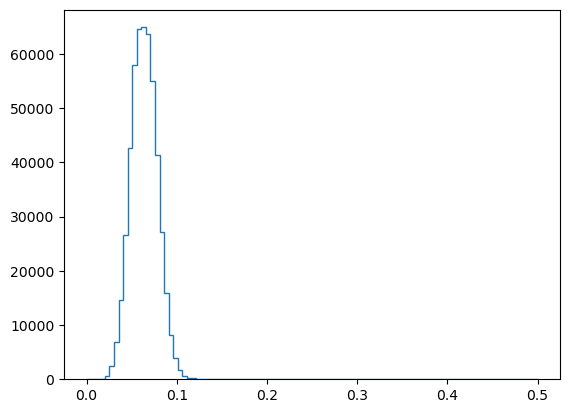

In [10]:
distances = np.linalg.norm(rd-corr_rd,axis=1)
h = plt.hist(distances,bins=np.linspace(0,0.5,100),histtype='step')
#plt.yscale('log')

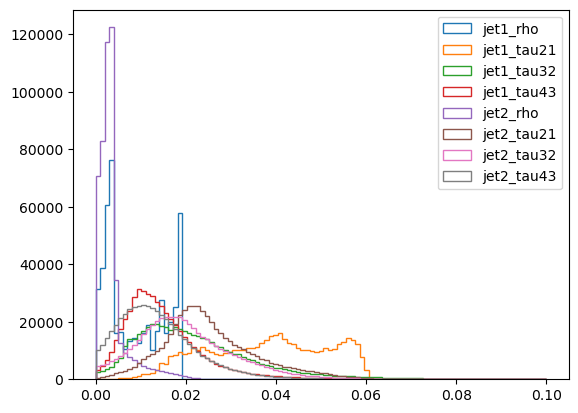

In [13]:
d = np.abs(rd-corr_rd)
vars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
for i in range(d.shape[1]):
    h = plt.hist(d[:,i],bins=np.linspace(0,0.1,100),histtype='step',label=vars[i])
plt.legend()

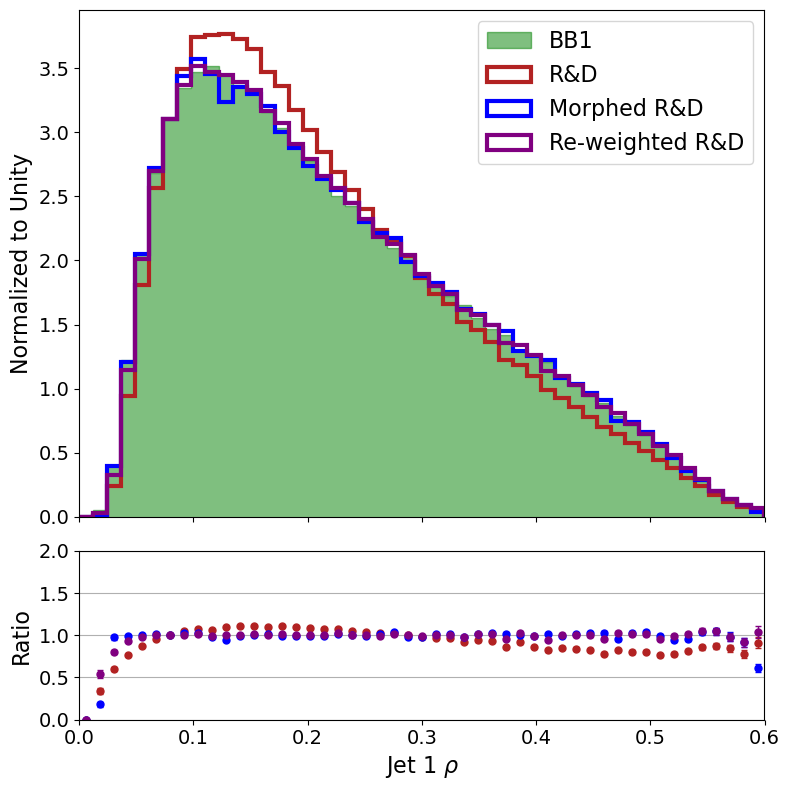

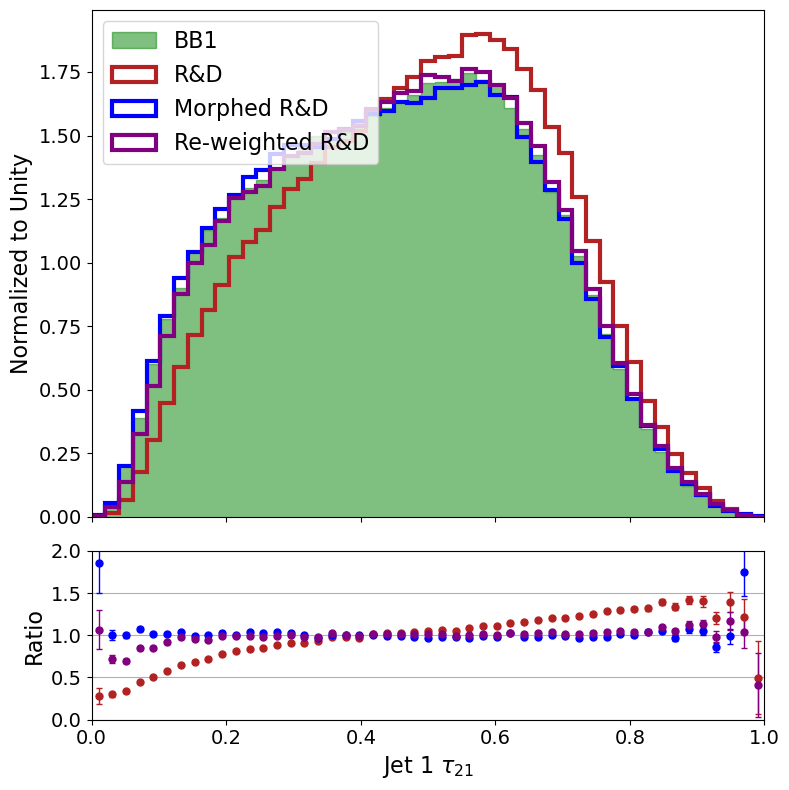

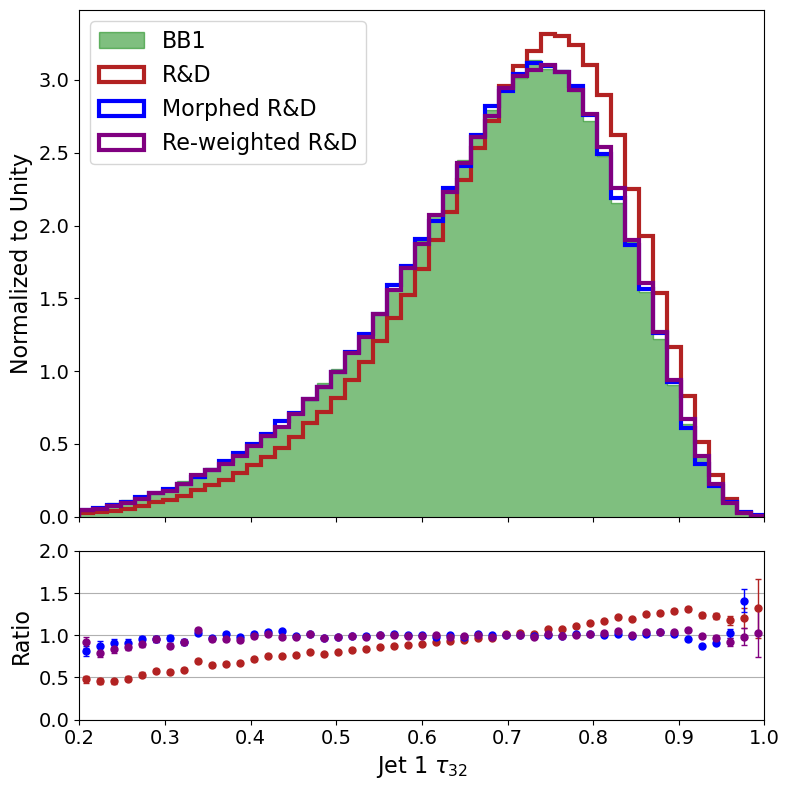

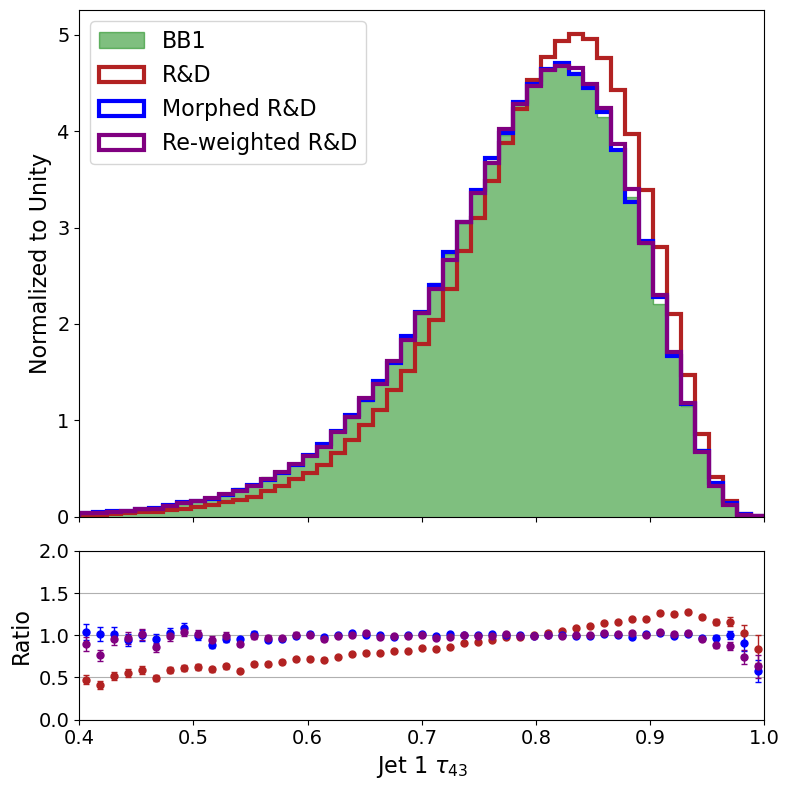

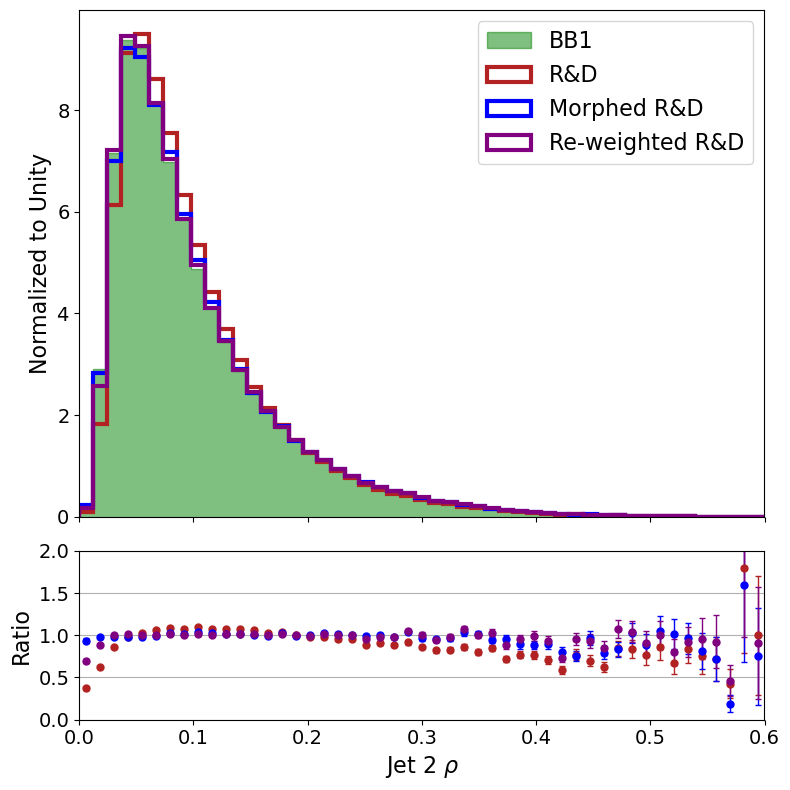

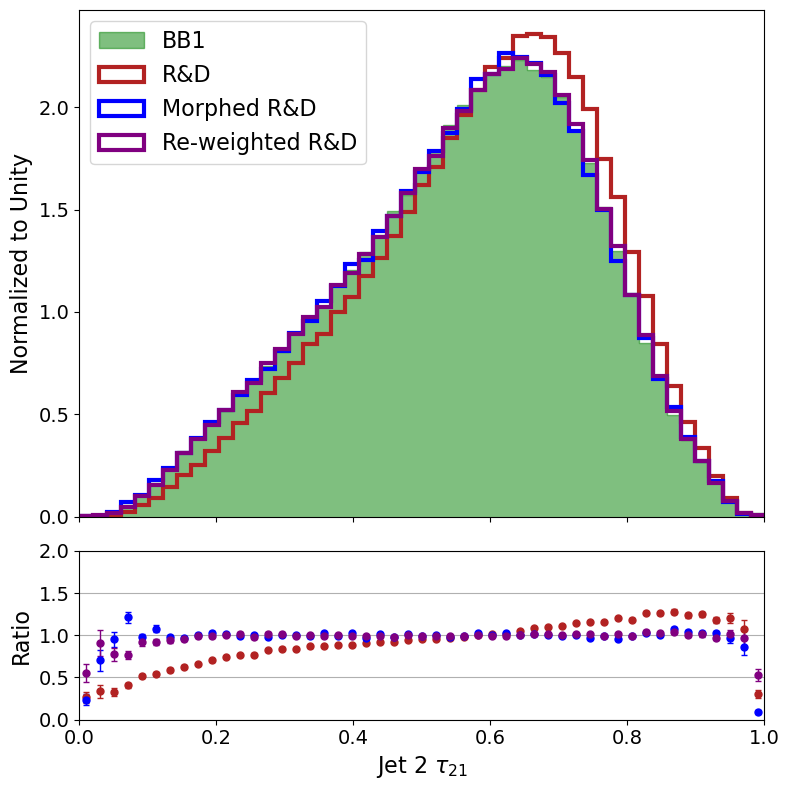

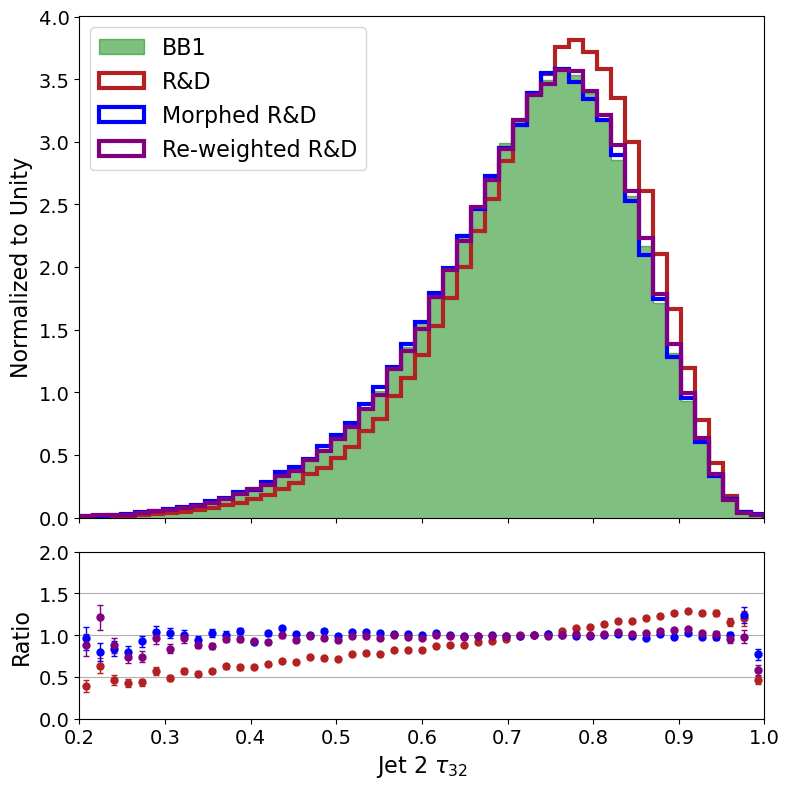

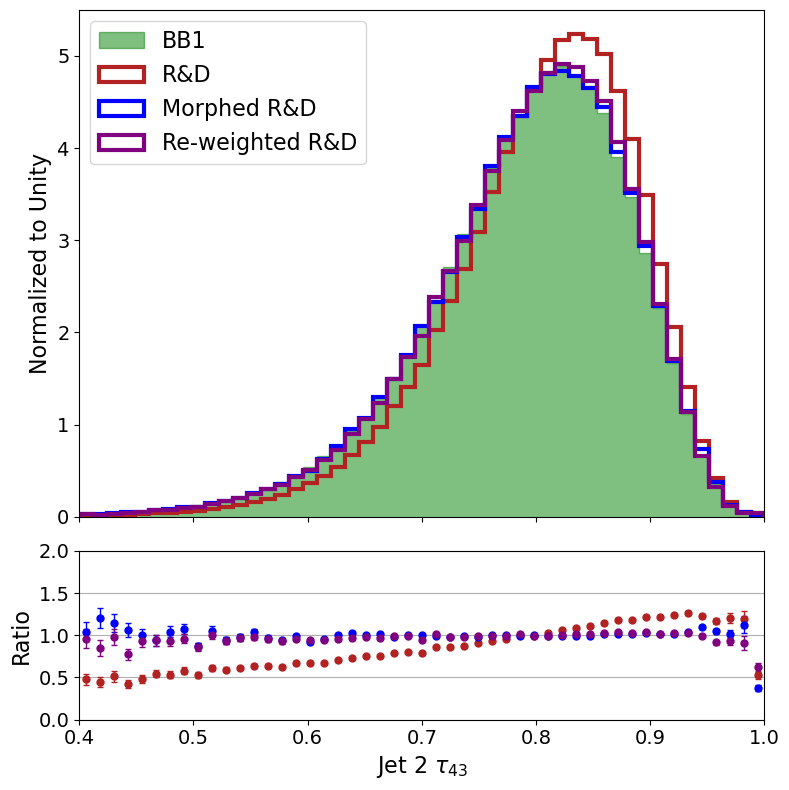

In [59]:
vars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
varNames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$",
               r"Jet 2 $\rho$",r"Jet 2 $\tau_{21}$",r"Jet 2 $\tau_{32}$",r"Jet 2 $\tau_{43}$"]

xlims = {
    "jet1_rho":[0,0.6],
    "jet1_tau21":[0,1],
    "jet1_tau32":[0.2,1],
    "jet1_tau43":[0.4,1],
    "jet2_rho":[0,0.6],
    "jet2_tau21":[0,1],
    "jet2_tau32":[0.2,1],
    "jet2_tau43":[0.4,1]
}
locs = {
    "jet1_rho":"upper right",
    "jet1_tau21":"upper left",
    "jet1_tau32":"upper left",
    "jet1_tau43":"upper left",
    "jet2_rho":"upper right",
    "jet2_tau21":"upper left",
    "jet2_tau32":"upper left",
    "jet2_tau43":"upper left"
}

for i in range(len(vars)):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    h_bb1, cts_bb1, bins = plotReference(bb1[:,i],axes[0],xlim=xlims[vars[i]],nbins=50,ylabel="Normalized to Unity",
                                         histtype='step',fill=True,color='green',alpha=0.5,label="BB1")
    plotRatio(axes,rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],
              color='firebrick',histtype='step',lw=3,label="R&D",markersize=10)
    plotRatio(axes,corr_rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],
              color='blue',histtype='step',lw=3,label="Morphed R&D",markersize=10)
    plotRatio(axes,rd[:,i],bins,h_bb1,cts_bb1,weights=rd_wgts,xlabel=varNames[i],
              color='purple',histtype='step',lw=3,label="Re-weighted R&D",markersize=10)
    plt.sca(axes[0])
    plt.legend(loc=locs[vars[i]],fontsize=16)
    plt.tight_layout()

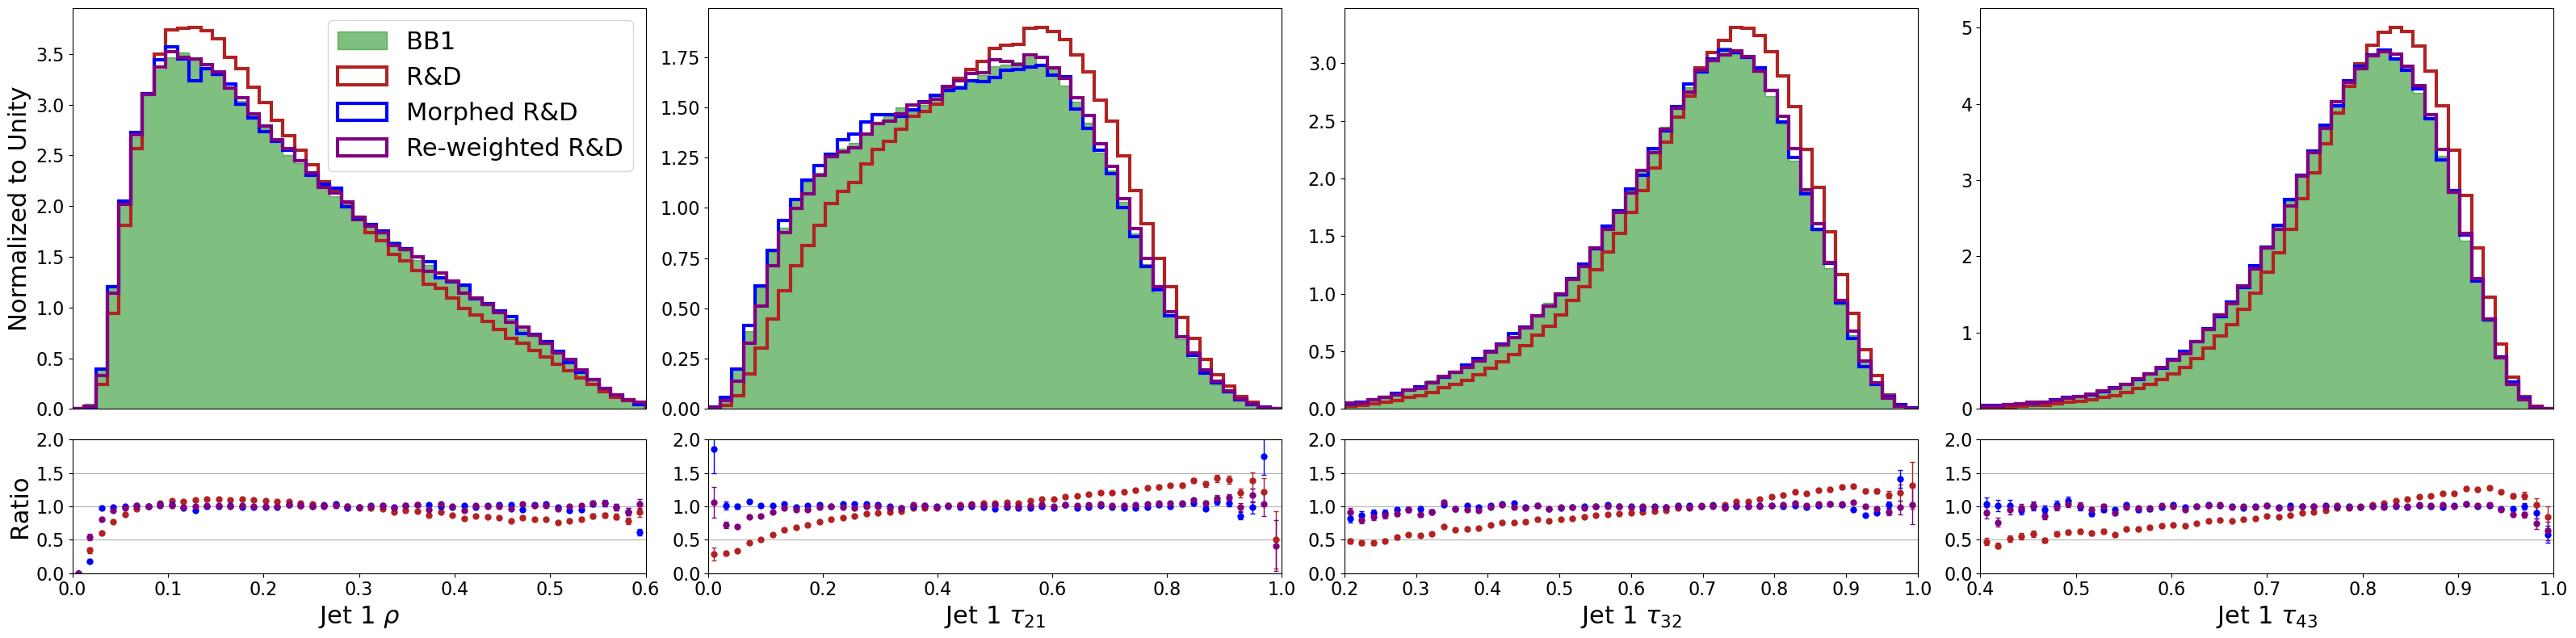

In [81]:
fig,axes = plt.subplots(figsize=(32,8),nrows=2,ncols=4,gridspec_kw={'height_ratios':[3,1]},sharex=False)
for i in range(4):
    do_ylabel = True if i==0 else False
    h_bb1, cts_bb1, bins = plotReference(bb1[:,i],axes[0,i],xlim=xlims[vars[i]],nbins=50,ylabel="Normalized to Unity",do_ylabel=do_ylabel,
                                         histtype='step',fill=True,color='green',alpha=0.5,label="BB1")
    plotRatio(axes[:,i],rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],do_ylabel=do_ylabel,
              color='firebrick',histtype='step',lw=3,label="R&D",markersize=10)
    plotRatio(axes[:,i],corr_rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],do_ylabel=do_ylabel,
              color='blue',histtype='step',lw=3,label="Morphed R&D",markersize=10)
    plotRatio(axes[:,i],rd[:,i],bins,h_bb1,cts_bb1,weights=rd_wgts,xlabel=varNames[i],do_ylabel=do_ylabel,
              color='purple',histtype='step',lw=3,label="Re-weighted R&D",markersize=10)
    plt.sca(axes[0,i])
    if i%4==0:
        plt.legend(loc=locs[vars[i]],fontsize=22)
    plt.xticks([],fontsize=0)
    plt.xlim(xlims[vars[i]])
    plt.sca(axes[1,i])
    plt.xlim(xlims[vars[i]])
    plt.tight_layout()
plt.savefig("jet1_highLevel_RDtoBB1.pdf")

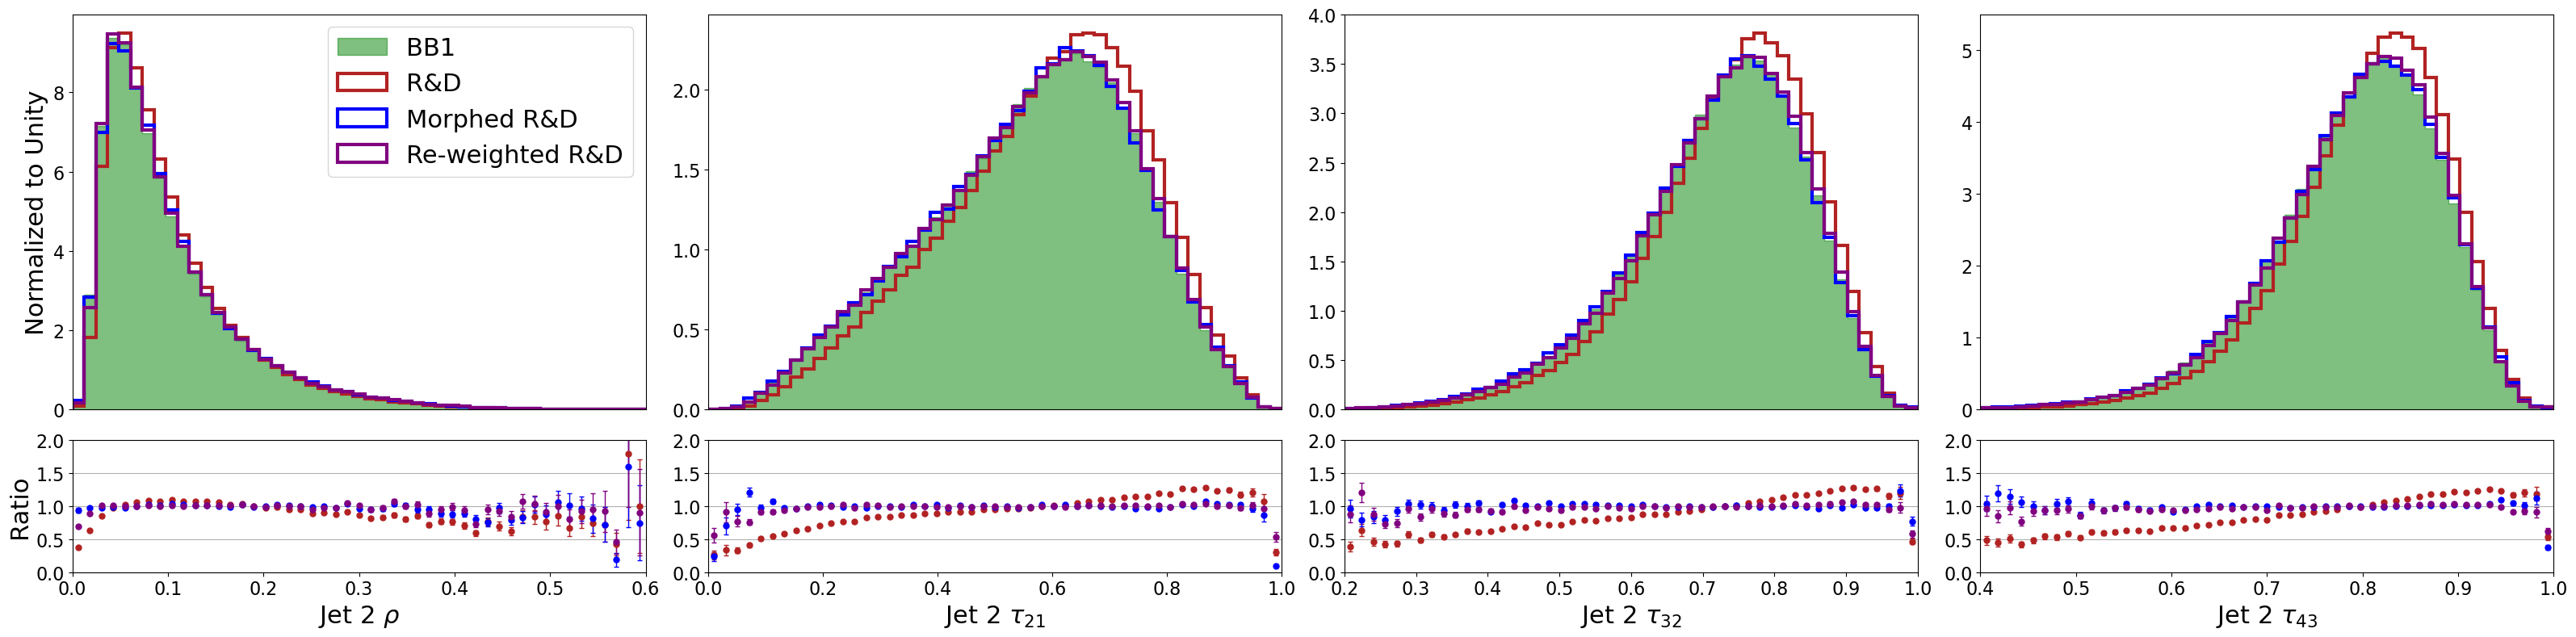

In [83]:
fig,axes = plt.subplots(figsize=(32,8),nrows=2,ncols=4,gridspec_kw={'height_ratios':[3,1]},sharex=False)
for i in range(4,8):
    do_ylabel = True if i-4==0 else False
    h_bb1, cts_bb1, bins = plotReference(bb1[:,i],axes[0,i-4],xlim=xlims[vars[i]],nbins=50,ylabel="Normalized to Unity",do_ylabel=do_ylabel,
                                         histtype='step',fill=True,color='green',alpha=0.5,label="BB1")
    plotRatio(axes[:,i-4],rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],do_ylabel=do_ylabel,
              color='firebrick',histtype='step',lw=3,label="R&D",markersize=10)
    plotRatio(axes[:,i-4],corr_rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],do_ylabel=do_ylabel,
              color='blue',histtype='step',lw=3,label="Morphed R&D",markersize=10)
    plotRatio(axes[:,i-4],rd[:,i],bins,h_bb1,cts_bb1,weights=rd_wgts,xlabel=varNames[i],do_ylabel=do_ylabel,
              color='purple',histtype='step',lw=3,label="Re-weighted R&D",markersize=10)
    plt.sca(axes[0,i-4])
    if i%4==0:
        plt.legend(loc=locs[vars[i]],fontsize=22)
    plt.xticks([],fontsize=0)
    plt.xlim(xlims[vars[i]])
    plt.sca(axes[1,i-4])
    plt.xlim(xlims[vars[i]])
    plt.tight_layout()
plt.savefig("jet2_highLevel_RDtoBB1.pdf")

In [9]:
# Evaluate nets I already trained to distinguish R&D from BB1
from sklearn.model_selection import train_test_split
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"

fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_val_idx = f['val_inds'][()]
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_val_idx = f['val_inds'][()]
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_val = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_val_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_val = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_val_idx]
# make train/test/val splits
rng1 = 42109
rng2 = 24513

b1_train, b1_test = train_test_split(np.concatenate((b1_test,b1_val),axis=0),
                                     train_size=0.5,random_state=rng1)
b1_test, b1_val = train_test_split(b1_test,train_size=0.5,random_state=rng2)

rd_train, rd_test = train_test_split(np.concatenate((rd_test,rd_val),axis=0),
                                     train_size=0.5,random_state=rng1)
rd_test, rd_val = train_test_split(rd_test,train_size=0.5,random_state=rng2)


train = np.concatenate((b1_train,rd_train),axis=0)
mean = train.mean(axis=0)
sd = train.std(axis=0)

del b1_train, b1_test, b1_val, rd_train, rd_test, rd_val, train

In [24]:
from sklearn.metrics import roc_auc_score
from qRegNN_NFs_general import NeuralNet
aucs = []
test_inputs = (np.concatenate((bb1,rd),axis=0)-mean)/sd
test_labels = np.concatenate((np.zeros(bb1.shape[0]),np.ones(rd.shape[0])),axis=0)
weights = np.concatenate((np.ones(bb1.shape[0]),rd_wgts),axis=0)
for i in range(10):
    net = torch.load(f"../NF_models_QR_general/LHCO_BB1toPythRD_jets12/NN_bb1_vs_rdPythia/training_{i}.pt").to(device)
    net.bn = False
    net.do_out = True
    net.out_act = nn.Sigmoid()
    with torch.no_grad():
        preds = net(torch.tensor(test_inputs,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0]
    del net
    torch.cuda.empty_cache()
    aucs.append(roc_auc_score(test_labels,preds,sample_weight=weights))
print(f"AUC = {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}")

AUC = 0.51584 +/- 0.00007


In [20]:
net.bn

AttributeError: 'NeuralNet' object has no attribute 'bn'

# High-level observables, mjj sideband

In [4]:
with h5py.File(fin,"r") as f:
    bb1_sb = f['RDtoBB1_mjjSB/bb1_sb'][()]
    rd_sb = f['RDtoBB1_mjjSB/rd_sb'][()]
    corr_rd_sb = f['RDtoBB1_mjjSB/corr_rd_sb'][()]
    bb1_sr = f['RDtoBB1_mjjSB/bb1_sr'][()]
    rd_sr = f['RDtoBB1_mjjSB/rd_sr'][()]
    corr_rd_sr = f['RDtoBB1_mjjSB/corr_rd_sr'][()]
    
# evaluate NN weights for re-weighting
wgt_net = torch.load("../reweighting_methods/dnn_jets12_highLevel_toReweightRD_mjjSideband.pt").to(device)
rd_sb_wgts = []
rd_sr_wgts = []
with h5py.File("../reweighting_methods/HL_meanStd_dnn_mjjSideband.h5","r") as f:
    mean = f['mean'][()]
    std = f['std'][()]
with torch.no_grad():
    split = np.array_split(np.arange(len(rd_sb)),len(rd_sb)//10000)
    for sp in split:
        rd_sb_wgts.append(wgt_net(torch.tensor((rd_sb[sp]-mean)/std,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])
    split = np.array_split(np.arange(len(rd_sr)),len(rd_sr)//10000)
    for sp in split:
        rd_sr_wgts.append(wgt_net(torch.tensor((rd_sr[sp]-mean)/std,dtype=torch.float32,device=device)).detach().cpu().numpy()[:,0])

rd_sb_wgts = np.concatenate(rd_sb_wgts,axis=0)
rd_sb_wgts = rd_sb_wgts/(1-rd_sb_wgts)

rd_sr_wgts = np.concatenate(rd_sr_wgts,axis=0)
rd_sr_wgts = rd_sr_wgts/(1-rd_sr_wgts)

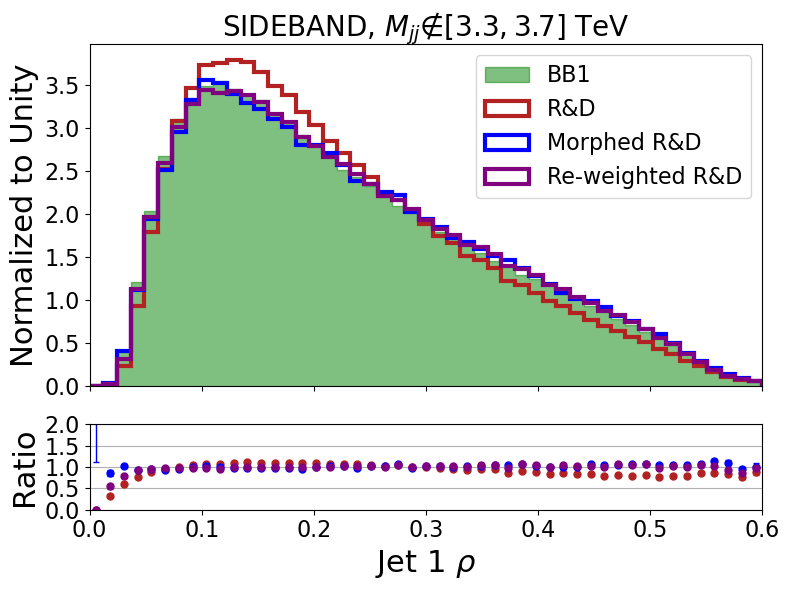

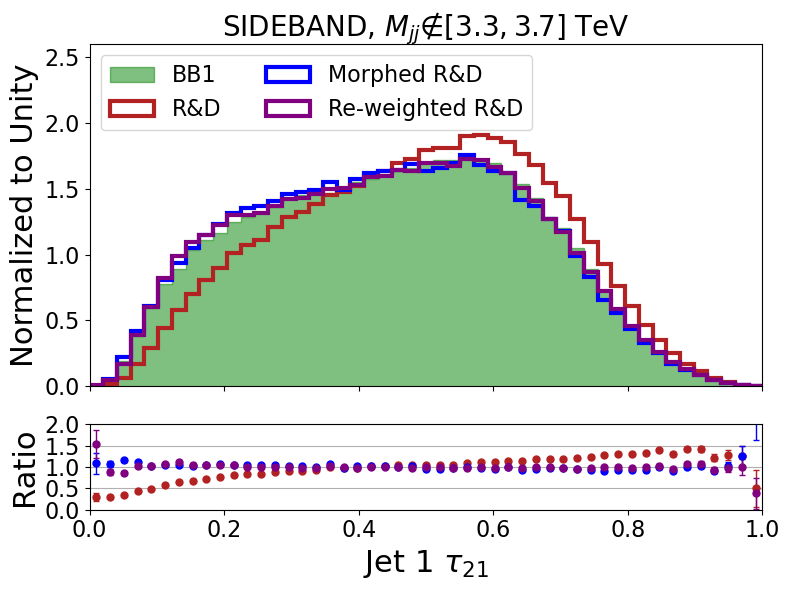

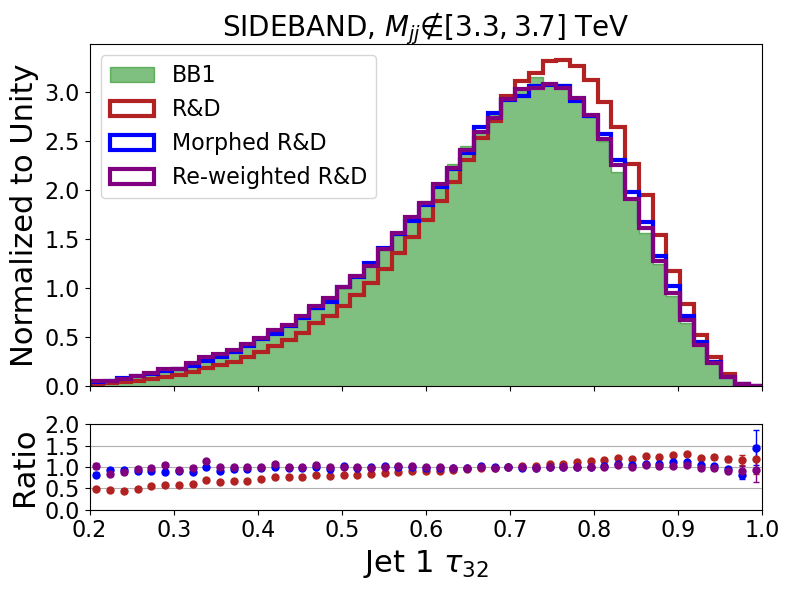

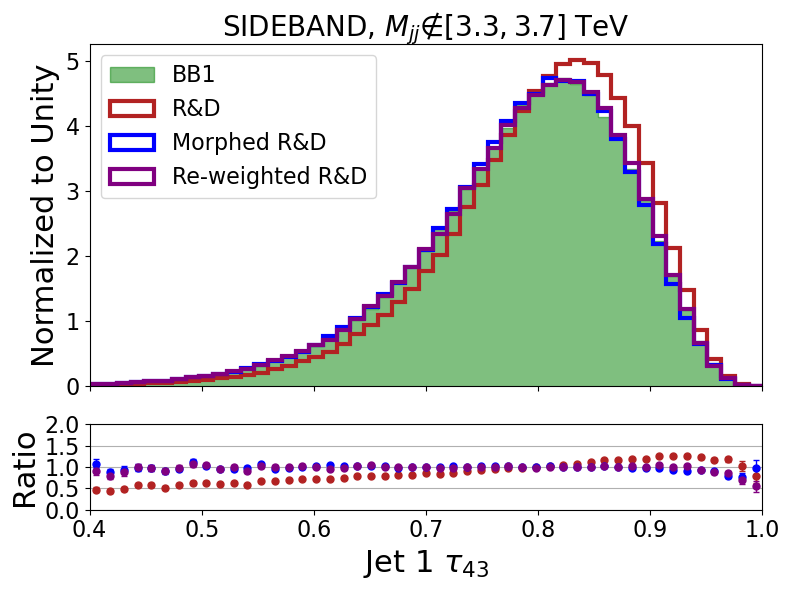

In [12]:
vars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
varNames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$",
               r"Jet 2 $\rho$",r"Jet 2 $\tau_{21}$",r"Jet 2 $\tau_{32}$",r"Jet 2 $\tau_{43}$"]

xlims = {
    "jet1_rho":[0,0.6],
    "jet1_tau21":[0,1],
    "jet1_tau32":[0.2,1],
    "jet1_tau43":[0.4,1],
    "jet2_rho":[0,0.6],
    "jet2_tau21":[0,1],
    "jet2_tau32":[0.2,1],
    "jet2_tau43":[0.4,1]
}
locs = {
    "jet1_rho":"upper right",
    "jet1_tau21":"upper left",
    "jet1_tau32":"upper left",
    "jet1_tau43":"upper left",
    "jet2_rho":"upper right",
    "jet2_tau21":"upper left",
    "jet2_tau32":"upper left",
    "jet2_tau43":"upper left"
}

for i in range(1,5):
    fig,axes = plt.subplots(figsize=(8,6),nrows=2,ncols=1,gridspec_kw={'height_ratios':[4,1]},sharex=True)
    h_bb1, cts_bb1, bins = plotReference(bb1_sb[:,i],axes[0],xlim=xlims[vars[i-1]],nbins=50,ylabel="Normalized to Unity",
                                         histtype='step',fill=True,color='green',alpha=0.5,label="BB1")
    plotRatio(axes,rd_sb[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i-1],
              color='firebrick',histtype='step',lw=3,label="R&D",markersize=10)
    plotRatio(axes,corr_rd_sb[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i-1],
              color='blue',histtype='step',lw=3,label="Morphed R&D",markersize=10)
    plotRatio(axes,rd_sb[:,i],bins,h_bb1,cts_bb1,weights=rd_sb_wgts,xlabel=varNames[i-1],
              color='purple',histtype='step',lw=3,label="Re-weighted R&D",markersize=10)
    plt.sca(axes[0])
    if vars[i-1] == "jet1_tau21":
        plt.ylim([0,2.6])
        plt.legend(loc=locs[vars[i-1]],fontsize=16,ncol=2)
    else:
        plt.legend(loc=locs[vars[i-1]],fontsize=16)
    plt.title(r"SIDEBAND, $M_{jj} \notin [3.3,3.7]$ TeV",fontsize=20)
    plt.tight_layout()
    plt.savefig(f"mjjSideband/{vars[i-1]}_sideband.pdf")

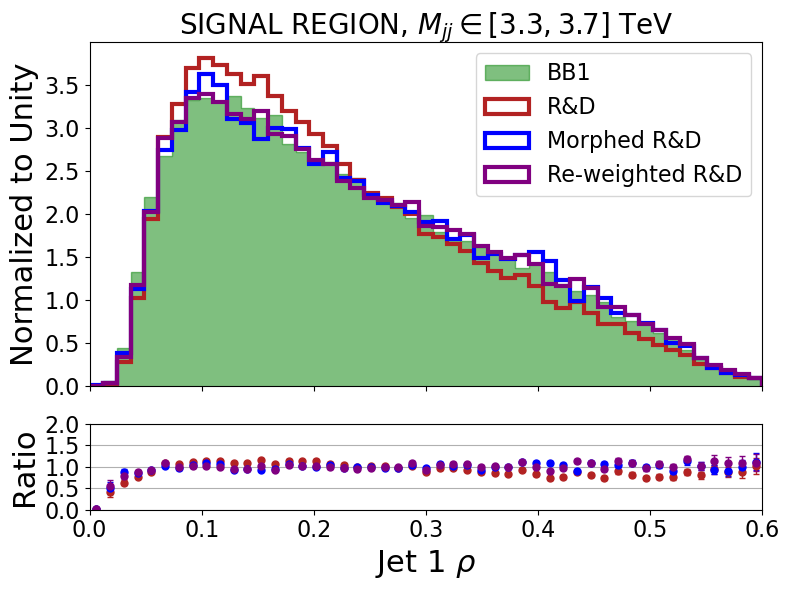

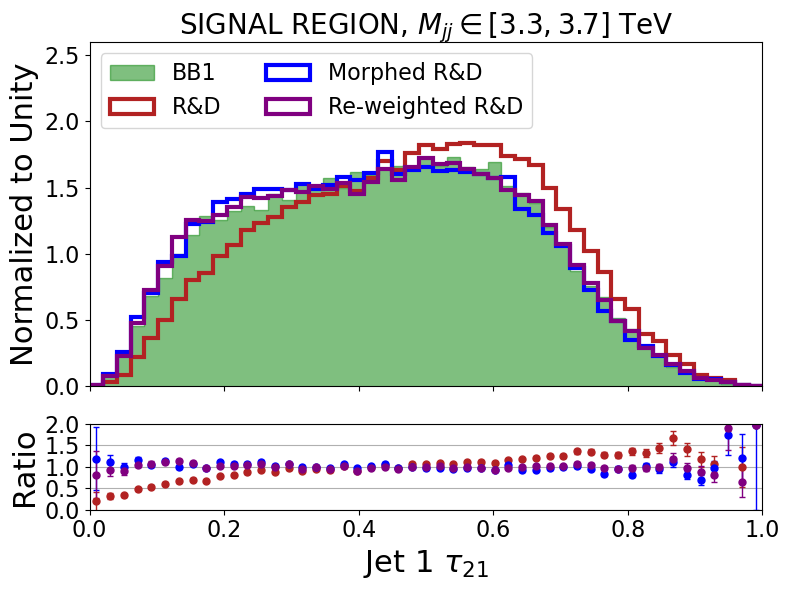

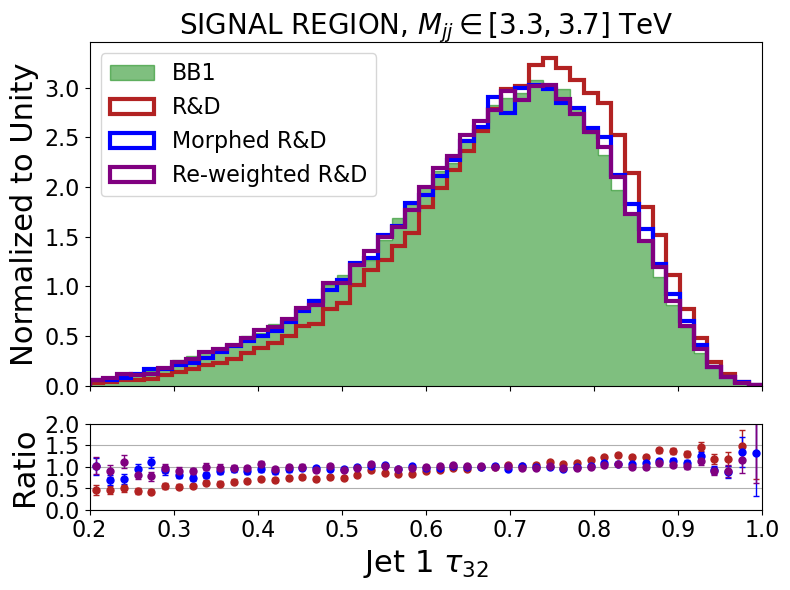

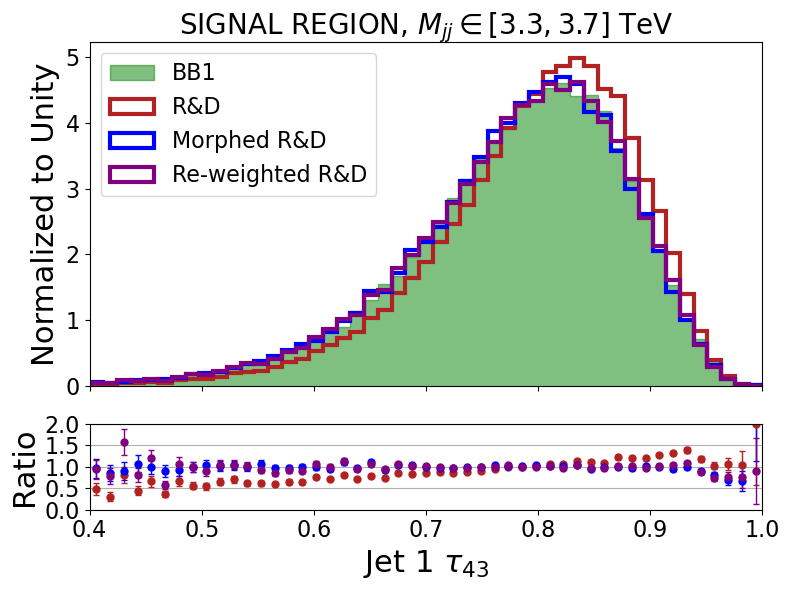

In [14]:
for i in range(1,5):
    fig,axes = plt.subplots(figsize=(8,6),nrows=2,ncols=1,gridspec_kw={'height_ratios':[4,1]},sharex=True)
    h_bb1, cts_bb1, bins = plotReference(bb1_sr[:,i],axes[0],xlim=xlims[vars[i-1]],nbins=50,ylabel="Normalized to Unity",
                                         histtype='step',fill=True,color='green',alpha=0.5,label="BB1")
    plotRatio(axes,rd_sr[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i-1],
              color='firebrick',histtype='step',lw=3,label="R&D",markersize=10)
    plotRatio(axes,corr_rd_sr[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i-1],
              color='blue',histtype='step',lw=3,label="Morphed R&D",markersize=10)
    plotRatio(axes,rd_sr[:,i],bins,h_bb1,cts_bb1,weights=rd_sr_wgts,xlabel=varNames[i-1],
              color='purple',histtype='step',lw=3,label="Re-weighted R&D",markersize=10)
    plt.sca(axes[0])
    if vars[i-1] == "jet1_tau21":
        plt.ylim([0,2.6])
        plt.legend(loc=locs[vars[i-1]],fontsize=16,ncol=2)
    else:
        plt.legend(loc=locs[vars[i-1]],fontsize=16)
    plt.title(r"SIGNAL REGION, $M_{jj} \in [3.3,3.7]$ TeV",fontsize=20)
    plt.tight_layout()
    plt.savefig(f"mjjSideband/{vars[i-1]}_sr.pdf")

Loss: 0.6932861804962158, p = 30: 100%|██████████| 439/439 [02:15<00:00,  3.24it/s] 


AUC = 0.51423 +/- 0.00064


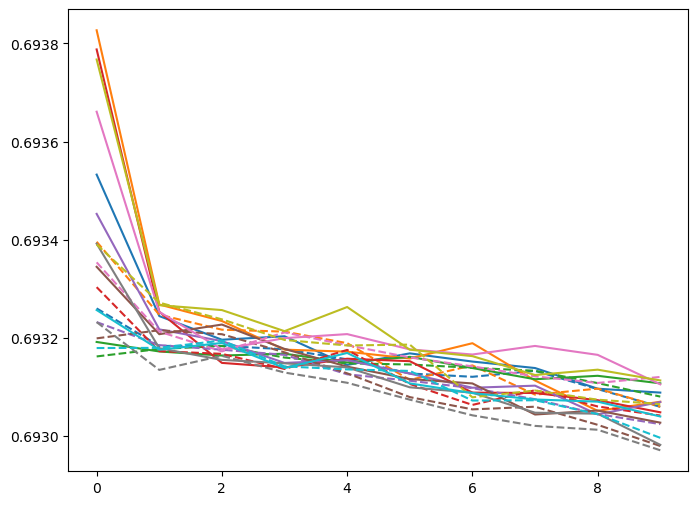

In [25]:
# train a neural net to distinguish corrected from original in sideband
alldata = np.concatenate((bb1_sb[:,1:],corr_rd_sb[:,1:]),axis=0)
labels = np.concatenate((np.zeros((bb1_sb.shape[0],1)),np.ones((corr_rd_sb.shape[0],1))),axis=0)
perm = np.random.permutation(alldata.shape[0])
alldata = alldata[perm]
labels = labels[perm]
mean = alldata.mean(axis=0)
std = alldata.std(axis=0)

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
train_idx, test_idx = train_test_split(np.arange(len(alldata)),train_size=0.5,shuffle=True)

train, test = alldata[train_idx], alldata[test_idx]
train_lab, test_lab = labels[train_idx], labels[test_idx]
train = (train-mean)/std
test = (test-mean)/std

n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10
aucs = []
plt.figure(figsize=(8,6))

for i in range(10):
    net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.25)
    net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,test,test_lab,n_epoch=10,lr=1e-4,
                                       bs=10000,lossfunc="BCE",plot=False,losses=True)
    torch.save(net1,f"mjjSideband/nets/nn_classifier_corrRDvsBB1_sb_iter{i}_noMass.pt")
    plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    plt.plot(np.arange(len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,dtype=torch.float32,device=device)).detach().cpu().numpy()
    aucs.append(roc_auc_score(test_lab,preds))
    del preds, net1
    torch.cuda.empty_cache()
print(f"AUC = {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}")

Loss: 0.6930099725723267, p = 92: 100%|██████████| 120/120 [00:39<00:00,  3.05it/s]


AUC = 0.50970 +/- 0.00396


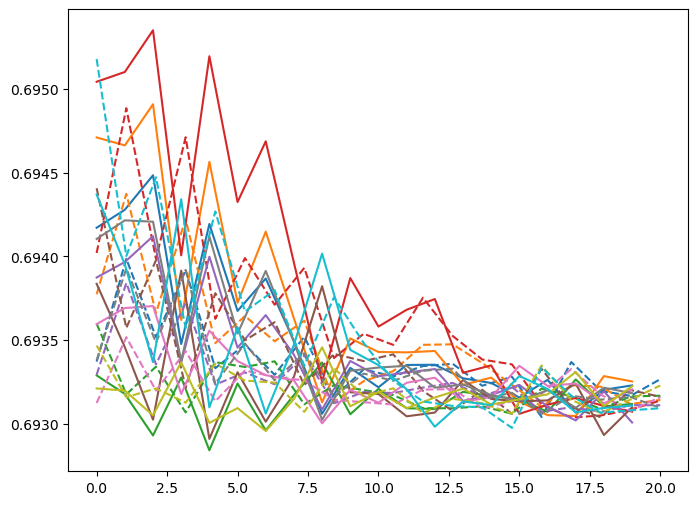

In [32]:
# train a neural net to distinguish corrected from original in SR
alldata = np.concatenate((bb1_sr[:,1:],corr_rd_sr[:,1:]),axis=0)
labels = np.concatenate((np.zeros((bb1_sr.shape[0],1)),np.ones((corr_rd_sr.shape[0],1))),axis=0)
perm = np.random.permutation(alldata.shape[0])
alldata = alldata[perm]
labels = labels[perm]
mean = alldata.mean(axis=0)
std = alldata.std(axis=0)

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
train_idx, test_idx = train_test_split(np.arange(len(alldata)),train_size=0.5,shuffle=True)

train, test = alldata[train_idx], alldata[test_idx]
train_lab, test_lab = labels[train_idx], labels[test_idx]
train = (train-mean)/std
test = (test-mean)/std

n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10
aucs = []
plt.figure(figsize=(8,6))

for i in range(10):
    net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,test,test_lab,n_epoch=20,lr=1e-4,
                                       bs=10000,lossfunc="BCE",plot=False,losses=True)
    torch.save(net1,f"mjjSideband/nets/nn_classifier_corrRDvsBB1_sr_iter{i}_noMass.pt")
    plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,dtype=torch.float32,device=device)).detach().cpu().numpy()
    aucs.append(roc_auc_score(test_lab,preds))
    del preds, net1
    torch.cuda.empty_cache()
print(f"AUC = {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}")

# High-level observables, contaminated training

In [10]:
with h5py.File(fin,"r") as f:
    bb1 = f['RDtoContamBB1/bb1'][()]
    rd = f['RDtoContamBB1/rd'][()]
    corr_rd = f['RDtoContamBB1/corr_rd'][()]

NameError: name 'plotReference' is not defined

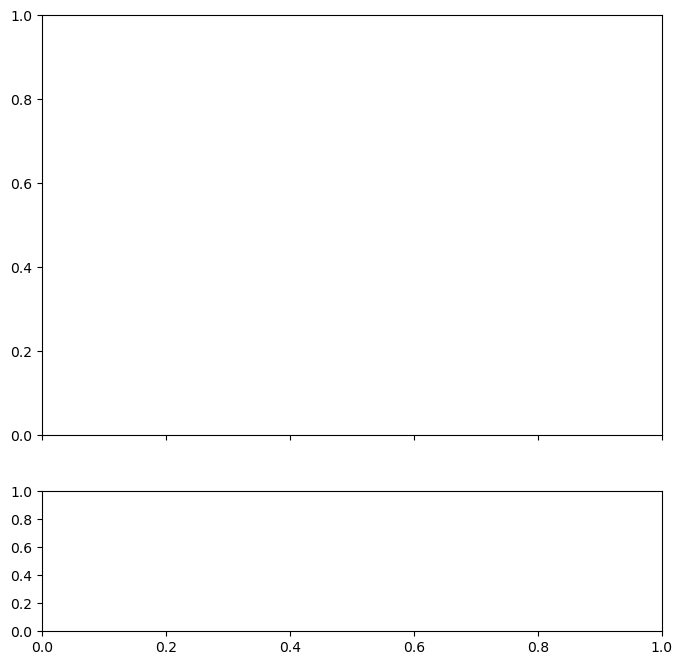

In [5]:
vars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']
varNames = [r"Jet 1 $\rho$",r"Jet 1 $\tau_{21}$",r"Jet 1 $\tau_{32}$",r"Jet 1 $\tau_{43}$",
               r"Jet 2 $\rho$",r"Jet 2 $\tau_{21}$",r"Jet 2 $\tau_{32}$",r"Jet 2 $\tau_{43}$"]

xlims = {
    "jet1_rho":[0,0.6],
    "jet1_tau21":[0,1],
    "jet1_tau32":[0.2,1],
    "jet1_tau43":[0.4,1],
    "jet2_rho":[0,0.6],
    "jet2_tau21":[0,1],
    "jet2_tau32":[0.2,1],
    "jet2_tau43":[0.4,1]
}
locs = {
    "jet1_rho":"upper right",
    "jet1_tau21":"upper left",
    "jet1_tau32":"upper left",
    "jet1_tau43":"upper left",
    "jet2_rho":"upper right",
    "jet2_tau21":"upper left",
    "jet2_tau32":"upper left",
    "jet2_tau43":"upper left"
}

for i in range(8):
    fig,axes = plt.subplots(figsize=(8,8),nrows=2,ncols=1,gridspec_kw={'height_ratios':[3,1]},sharex=True)
    h_bb1, cts_bb1, bins = plotReference(bb1[:,i],axes[0],xlim=xlims[vars[i]],nbins=50,ylabel="Normalized to Unity",
                                         histtype='step',fill=True,color='green',alpha=0.5,label="BB1")
    plotRatio(axes,rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],
              color='firebrick',histtype='step',lw=3,label="R&D",markersize=10)
    plotRatio(axes,corr_rd[:,i],bins,h_bb1,cts_bb1,weights=None,xlabel=varNames[i],
              color='blue',histtype='step',lw=3,label="Morphed R&D",markersize=10)
    #plotRatio(axes,rd_sb[:,i],bins,h_bb1,cts_bb1,weights=rd_sb_wgts,xlabel=varNames[i-1],
    #          color='purple',histtype='step',lw=3,label="Re-weighted R&D",markersize=10)
    plt.sca(axes[0])
    if vars[i] == "jet1_tau21":
        plt.ylim([0,2.5])
        plt.legend(loc=locs[vars[i]],fontsize=16,ncol=2)
    else:
        plt.legend(loc=locs[vars[i]],fontsize=16)
    plt.sca(axes[1])
    plt.grid(axis='y')
    #plt.tight_layout()
    #plt.savefig(f"mjjSideband/{vars[i-1]}_sideband.pdf")

Loss: 0.6930031776428223, p = 122: 100%|██████████| 749/749 [03:43<00:00,  3.35it/s]


AUC = 0.51353 +/- 0.00047


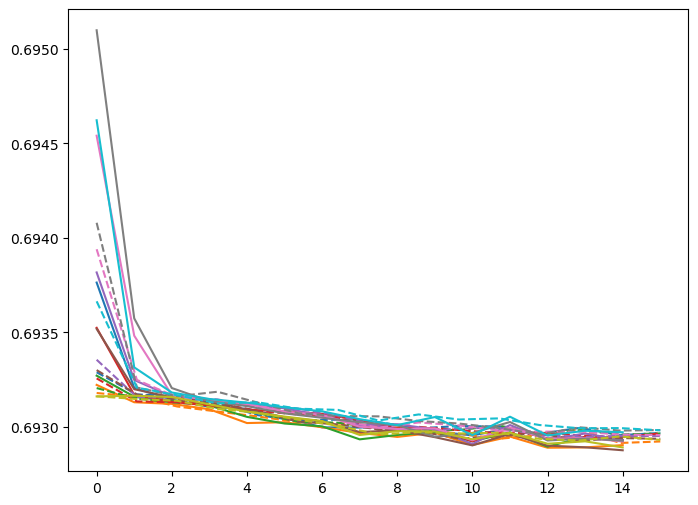

In [11]:
alldata = np.concatenate((bb1[:,1:],corr_rd[:,1:]),axis=0)
labels = np.concatenate((np.zeros((bb1.shape[0],1)),np.ones((corr_rd.shape[0],1))),axis=0)
perm = np.random.permutation(alldata.shape[0])
alldata = alldata[perm]
labels = labels[perm]
mean = alldata.mean(axis=0)
std = alldata.std(axis=0)

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
train_idx, test_idx = train_test_split(np.arange(len(alldata)),train_size=0.5,shuffle=True)

train, test = alldata[train_idx], alldata[test_idx]
train_lab, test_lab = labels[train_idx], labels[test_idx]
train = (train-mean)/std
test = (test-mean)/std

n_in = train.shape[1]
n_hidden = 64
num_hidden = 6
n_out = 1
act = nn.ReLU()
out_act = nn.Sigmoid()

n_iter = 10
aucs = []
plt.figure(figsize=(8,6))

for i in range(10):
    net1 = qrnn.NeuralNet(n_in, n_hidden, n_out, num_hidden, act=act, out_act=out_act,dropout=0.1)
    net1,loss,val_loss = qrnn.train_nn(net1,train,train_lab,test,test_lab,n_epoch=15,lr=1e-4,
                                       bs=10000,lossfunc="BCE",plot=False,losses=True)
    torch.save(net1,f"contamTraining/nets/nn_classifier_corrRDvsBB1_iter{i}.pt")
    plt.plot(np.arange(len(loss)),loss,color=f"C{i}")
    plt.plot(np.linspace(0,len(loss),len(val_loss)),val_loss,color=f"C{i}",linestyle='--')
    net1 = net1.to(device)
    with torch.no_grad():
        preds = net1(torch.tensor(test,dtype=torch.float32,device=device)).detach().cpu().numpy()
    aucs.append(roc_auc_score(test_lab,preds))
    del preds, net1
    torch.cuda.empty_cache()
print(f"AUC = {np.mean(aucs):.5f} +/- {np.std(aucs):.5f}")

In [12]:
bb1.shape

(499583, 8)